# 02a -- Process Discovery

Applies and compares four process discovery algorithms on the consolidated hiring-process event log.

| # | Algorithm | Paradigm | Reference |
|---|-----------|----------|-----------|
| 1 | **Alpha Miner** | Rule-based (footprint matrix) | van der Aalst et al. (2004) |
| 2 | **Inductive Miner** | Divide-and-conquer (cut detection) | Leemans et al. (2013) |
| 3 | **Heuristics Miner** | Frequency/dependency thresholds | Weijters & Ribeiro (2011) |
| 4 | **GNN Miner** | Graph Neural Network edge prediction | Sommers et al., ICPM 2021 |

**Input:** `data/event_log_consolidated.csv`  
**Key columns:** `Case_id` (case), `Step` (activity), `timestamp`


## 0 . Setup


In [15]:
import warnings
warnings.filterwarnings('ignore')

import os, tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

import pm4py
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.algo.discovery.dfg import algorithm as dfg_algorithm
from pm4py.statistics.start_activities.log import get as sa_get
from pm4py.statistics.end_activities.log import get as ea_get
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator

os.makedirs('output', exist_ok=True)
torch.manual_seed(42)
np.random.seed(42)

print(f'pm4py  : {pm4py.__version__}')
print(f'PyTorch: {torch.__version__}')


pm4py  : 2.7.19.8
PyTorch: 2.10.0+cu126


## 1 . Load & Preprocess Event Log


In [16]:
df_raw = pd.read_csv('data/event_log_consolidated.csv')

df = df_raw.rename(columns={
    'Case_id':   'case:concept:name',
    'Step':      'concept:name',
    'timestamp': 'time:timestamp',
}).copy()

df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
df = df.sort_values(['case:concept:name', 'time:timestamp']).reset_index(drop=True)

print(f'Events     : {len(df):,}')
print(f'Cases      : {df["case:concept:name"].nunique():,}')
print(f'Activities : {df["concept:name"].nunique()}')
print(f'Date range : {df["time:timestamp"].min().date()} to {df["time:timestamp"].max().date()}')
print('Activity frequencies:')
print(df['concept:name'].value_counts().to_string())


Events     : 1,123,421
Cases      : 279,458
Activities : 54
Date range : 2021-01-06 to 2026-02-12
Activity frequencies:
concept:name
Start                                                            284587
Review Decision                                                  268611
Manager Screen                                                    59666
Screen                                                            51428
Schedule Interview                                                40907
Provide Interview Rating and Comments                             40506
Make Interview Decision                                           40395
Assess Candidate                                                  27978
Make Assessment Decision                                          27977
Recruiter Interview                                               27888
Assessment                                                        27300
HireVue Assessment                                                26975
Ser

In [ ]:
df_pm = dataframe_utils.convert_timestamp_columns_in_df(df.copy())
log   = log_converter.apply(df_pm, variant=log_converter.Variants.TO_EVENT_LOG)

activities = sorted(df['concept:name'].unique().tolist())
act2idx    = {a: i for i, a in enumerate(activities)}
n_acts     = len(activities)

print(f'pm4py EventLog: {len(log):,} traces | {sum(len(t) for t in log):,} events')


### Helpers


In [ ]:
def show_petri_net(net, im, fm, title='', figsize=(16, 6)):
    gviz = pn_visualizer.apply(
        net, im, fm,
        parameters={pn_visualizer.Variants.WO_DECORATION.value.Parameters.FORMAT: 'png'}
    )
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
        pn_visualizer.save(gviz, tmp.name)
        img = plt.imread(tmp.name)
    os.unlink(tmp.name)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()


def evaluate_model(net, im, fm, log):
    results = {}
    try:
        fit = replay_fitness.apply(log, net, im, fm, variant=replay_fitness.Variants.TOKEN_BASED)
        results['fitness'] = round(fit['average_trace_fitness'], 4)
    except Exception:
        results['fitness'] = None
    try:
        prec = precision_evaluator.apply(log, net, im, fm, variant=precision_evaluator.Variants.ETCONFORMANCE_TOKEN)
        results['precision'] = round(prec, 4)
    except Exception:
        results['precision'] = None
    try:
        results['simplicity'] = round(simplicity_evaluator.apply(net), 4)
    except Exception:
        results['simplicity'] = None
    results['places']      = len(net.places)
    results['transitions'] = len(net.transitions)
    results['arcs']        = len(net.arcs)
    return results


scoreboard = {}


---
## 2 . Alpha Miner

The **Alpha Miner** (van der Aalst et al., 2004) derives a workflow net from the *footprint matrix* -- 
it encodes causality, parallelism, and choice relations by scanning which activities co-appear in direct succession.

**Limitations:** cannot handle short loops, non-free-choice constructs, or noisy logs.


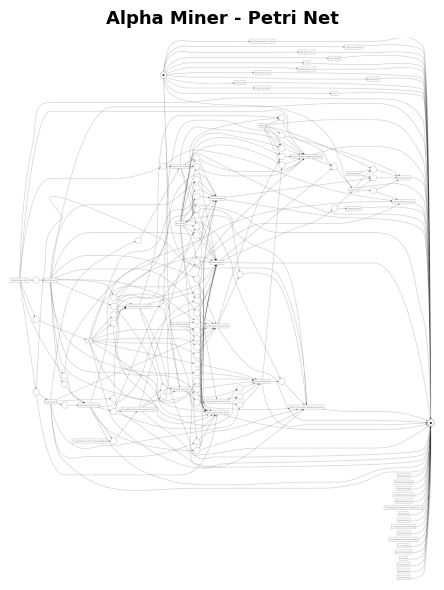

replaying log with TBR, completed traces ::   0%|          | 0/16256 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/133284 [00:00<?, ?it/s]

Alpha Miner metrics:
  fitness     : 0.5452
  precision   : 0.1948
  simplicity  : 0.2808
  places      : 60
  transitions : 54
  arcs        : 260


In [ ]:
net_alpha, im_alpha, fm_alpha = alpha_miner.apply(log)
show_petri_net(net_alpha, im_alpha, fm_alpha, title='Alpha Miner - Petri Net')
metrics_alpha = evaluate_model(net_alpha, im_alpha, fm_alpha, log)
scoreboard['Alpha'] = metrics_alpha
print('Alpha Miner metrics:')
for k, v in metrics_alpha.items(): print(f'  {k:12s}: {v}')


---
## 3 . Inductive Miner

The **Inductive Miner** (Leemans et al., 2013) recursively detects *cuts* (sequence, choice, parallel, loop) in the DFG, 
guaranteeing a **sound** workflow net. Variant IMf filters low-frequency behaviour.

Parameters: `noise_threshold = 0.2`


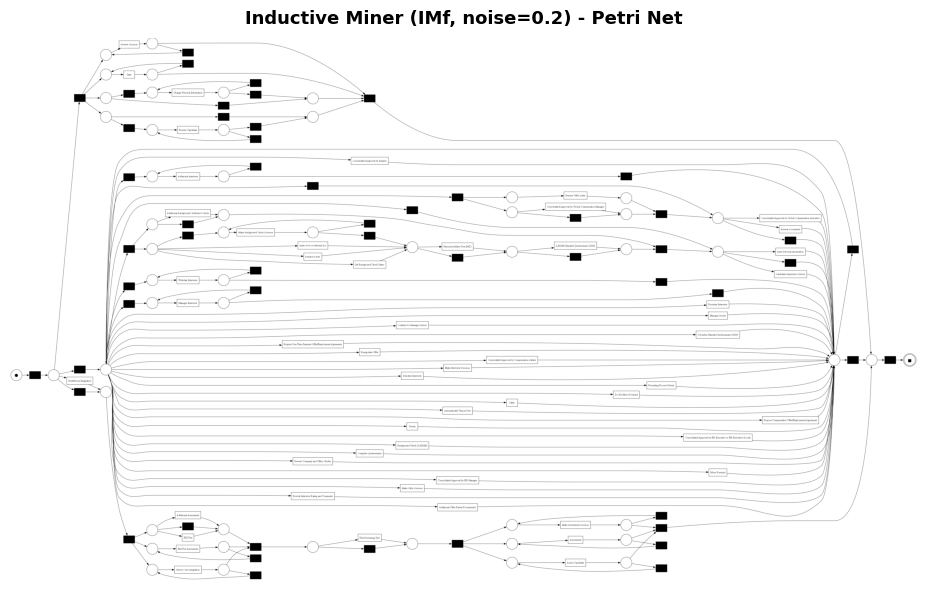

replaying log with TBR, completed traces ::   0%|          | 0/16256 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/133284 [00:00<?, ?it/s]

Inductive Miner metrics:
  fitness     : 0.9291
  precision   : 0.3585
  simplicity  : 0.5263
  places      : 53
  transitions : 107
  arcs        : 232


In [ ]:
net_inductive, im_inductive, fm_inductive = pm4py.discover_petri_net_inductive(
    log, noise_threshold=0.2
)

show_petri_net(net_inductive, im_inductive, fm_inductive,
               title='Inductive Miner (IMf, noise=0.2) - Petri Net')

metrics_inductive = evaluate_model(net_inductive, im_inductive, fm_inductive, log)
scoreboard['Inductive'] = metrics_inductive
print('Inductive Miner metrics:')
for k, v in metrics_inductive.items(): print(f'  {k:12s}: {v}')


---
## 4 . Heuristics Miner

The **Heuristics Miner** (Weijters & Ribeiro, 2011) uses *dependency ratios* from directly-follows frequencies 
to filter noise. It tolerates short loops, trading soundness for flexibility.

Parameters: `dependency_threshold=0.5`, `min_act_count=5`, `min_dfg_occurrences=5`


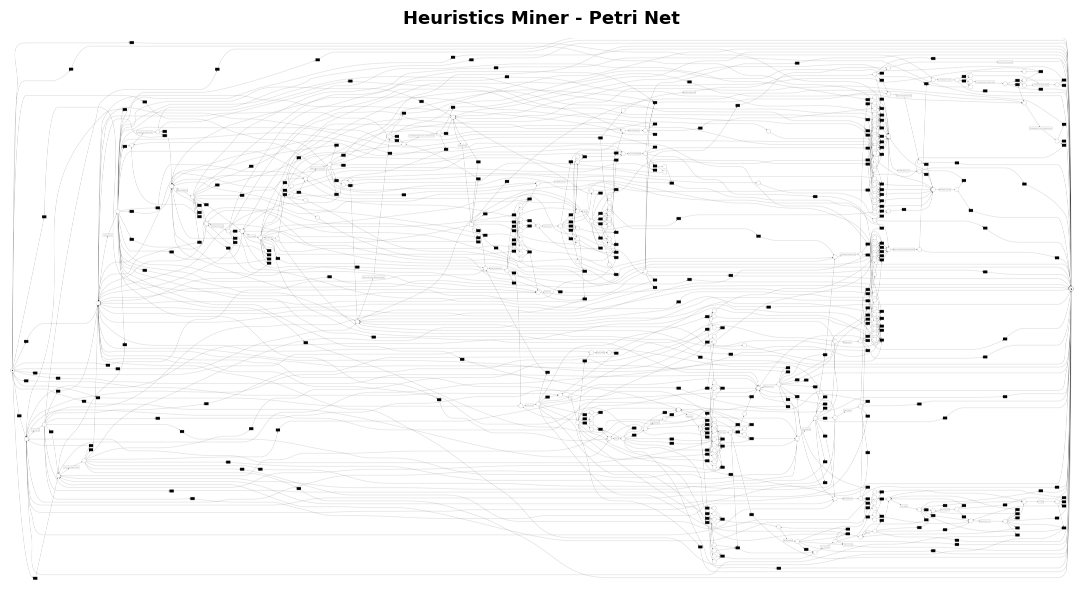

replaying log with TBR, completed traces ::   0%|          | 0/16256 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/133284 [00:00<?, ?it/s]

Heuristics Miner metrics:
  fitness     : 0.9457
  precision   : 0.9936
  simplicity  : 0.427
  places      : 210
  transitions : 392
  arcs        : 1006


In [ ]:
net_heuristics, im_heuristics, fm_heuristics = heuristics_miner.apply(
    log,
    parameters={
        heuristics_miner.Variants.CLASSIC.value.Parameters.DEPENDENCY_THRESH:   0.5,
        heuristics_miner.Variants.CLASSIC.value.Parameters.MIN_ACT_COUNT:       5,
        heuristics_miner.Variants.CLASSIC.value.Parameters.MIN_DFG_OCCURRENCES: 5,
    }
)

show_petri_net(net_heuristics, im_heuristics, fm_heuristics,
               title='Heuristics Miner - Petri Net')

metrics_heuristics = evaluate_model(net_heuristics, im_heuristics, fm_heuristics, log)
scoreboard['Heuristics'] = metrics_heuristics
print('Heuristics Miner metrics:')
for k, v in metrics_heuristics.items(): print(f'  {k:12s}: {v}')


---
## 5 . GNN Process Discovery

Based on **Sommers et al. (2021)** -- *Process Discovery using Graph Neural Networks*, ICPM 2021.

### Approach

1. **Build a graph**: activities = nodes; directly-follows pairs = directed weighted edges.
2. **Node features** (5-dim): frequency, P(start), P(end), avg normalised trace-position, std position.
3. **2-layer GCN encoder** propagates neighbourhood information -> activity embeddings h in R^16.
4. **Bilinear edge predictor**: trained on link-prediction objective (is (a_i -> a_j) in the model?).
5. **Threshold at 0.5** to obtain the final directed process graph.

### Architecture

```
x in R^5  ->  GCNLayer(5->32)  ->  GCNLayer(32->16)  ->  h in R^16
                                                             |
                               score(i,j) = sigmoid(h_i^T W h_j + b)
```


### 5.1 Build DFG and Node Features


In [ ]:
dfg        = dfg_algorithm.apply(log)
start_acts = sa_get.get_start_activities(log)
end_acts   = ea_get.get_end_activities(log)

total_start = max(sum(start_acts.values()), 1)
total_end   = max(sum(end_acts.values()), 1)

df_feat = df[['case:concept:name', 'concept:name']].copy()
df_feat['case_len']   = df_feat.groupby('case:concept:name')['concept:name'].transform('count')
df_feat['event_rank'] = df_feat.groupby('case:concept:name').cumcount()
df_feat['norm_pos']   = df_feat['event_rank'] / df_feat['case_len'].clip(lower=2).sub(1)
pos_stats = df_feat.groupby('concept:name')['norm_pos'].agg(['mean', 'std']).fillna(0)
act_freq  = df['concept:name'].value_counts() / len(df)

node_feats = []
for act in activities:
    node_feats.append([
        float(act_freq.get(act, 0)),
        start_acts.get(act, 0) / total_start,
        end_acts.get(act, 0)   / total_end,
        float(pos_stats.loc[act, 'mean']) if act in pos_stats.index else 0.5,
        float(pos_stats.loc[act, 'std'])  if act in pos_stats.index else 0.0,
    ])
X = torch.tensor(node_feats, dtype=torch.float32)

dfg_matrix = np.zeros((n_acts, n_acts))
for (src, dst), cnt in dfg.items():
    if src in act2idx and dst in act2idx:
        dfg_matrix[act2idx[src], act2idx[dst]] = cnt

A      = torch.tensor(dfg_matrix / max(dfg_matrix.sum(), 1), dtype=torch.float32)
A_self = A + torch.eye(n_acts)
deg    = A_self.sum(dim=1).clamp(min=1e-9)
D_inv  = torch.diag(1.0 / deg.sqrt())
A_hat  = D_inv @ A_self @ D_inv

nz        = dfg_matrix[dfg_matrix > 0]
threshold = float(np.median(nz)) if len(nz) > 0 else 0.0

src_list, dst_list, labels = [], [], []
for i in range(n_acts):
    for j in range(n_acts):
        if i != j:
            src_list.append(i)
            dst_list.append(j)
            labels.append(1 if dfg_matrix[i, j] > threshold else 0)
src_idx = torch.tensor(src_list)
dst_idx = torch.tensor(dst_list)
y       = torch.tensor(labels, dtype=torch.float32)

print(f'Activities              : {n_acts}')
print(f'DFG edges (any freq)    : {int((dfg_matrix > 0).sum())}')
print(f'Frequency threshold     : {threshold:.1f}')
print(f'Positive edges (label=1): {int(y.sum())}')
print(f'Negative edges (label=0): {int((y==0).sum())}')


Activities              : 54
DFG edges (any freq)    : 1069
Frequency threshold     : 15.0
Positive edges (label=1): 514
Negative edges (label=0): 2348


### 5.2 GNN Architecture


In [ ]:
class GCNLayer(nn.Module):
    """h' = ReLU(A_hat @ X @ W)"""
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.linear  = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, X, A_hat):
        return F.relu(self.linear(self.dropout(A_hat @ X)))


class GNNProcessDiscovery(nn.Module):
    """
    GNN for process discovery via edge prediction.
    Encoder: 2-layer GCN producing activity embeddings.
    Decoder: bilinear scorer  score(i,j) = sigma(h_i^T W h_j + b).
    Reference: Sommers et al. (2021), ICPM 2021.
    """
    def __init__(self, in_dim, hidden_dim, embed_dim, dropout=0.3):
        super().__init__()
        self.gcn1        = GCNLayer(in_dim,     hidden_dim, dropout)
        self.gcn2        = GCNLayer(hidden_dim, embed_dim,  dropout)
        self.edge_scorer = nn.Bilinear(embed_dim, embed_dim, 1)

    def encode(self, X, A_hat):
        return self.gcn2(self.gcn1(X, A_hat), A_hat)

    def decode(self, h, src, dst):
        return torch.sigmoid(self.edge_scorer(h[src], h[dst])).squeeze(-1)

    def forward(self, X, A_hat, src, dst):
        return self.decode(self.encode(X, A_hat), src, dst)


model = GNNProcessDiscovery(in_dim=X.shape[1], hidden_dim=32, embed_dim=16, dropout=0.3)
print(model)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters()):,}')


GNNProcessDiscovery(
  (gcn1): GCNLayer(
    (linear): Linear(in_features=5, out_features=32, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (gcn2): GCNLayer(
    (linear): Linear(in_features=32, out_features=16, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (edge_scorer): Bilinear(in1_features=16, in2_features=16, out_features=1, bias=True)
)
Trainable parameters: 977


### 5.3 Training


Epoch  100/400 | Loss: 1.0653 | Acc: 0.5486
Epoch  200/400 | Loss: 1.0274 | Acc: 0.5328
Epoch  300/400 | Loss: 1.0155 | Acc: 0.4822
Epoch  400/400 | Loss: 0.9745 | Acc: 0.5758


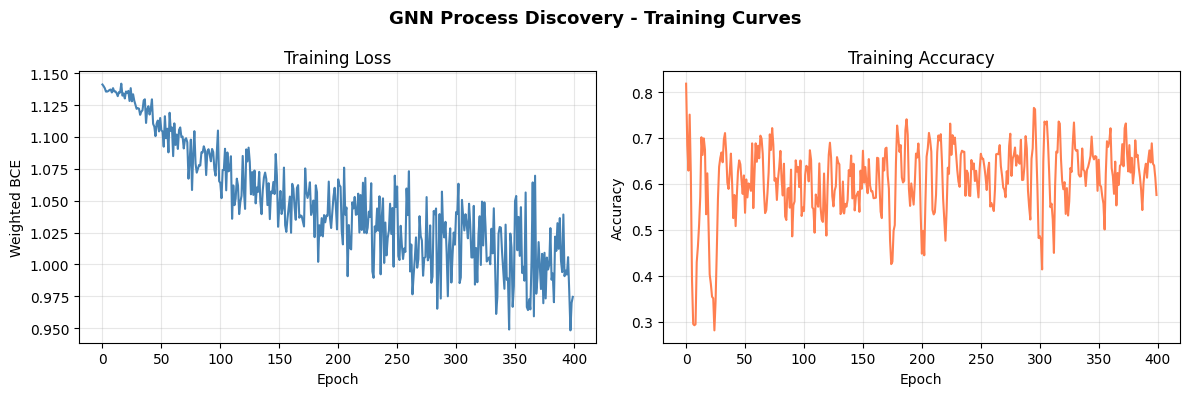

In [ ]:
pos_weight = float((y == 0).sum() / max((y == 1).sum(), 1))
optimizer  = Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
bce        = nn.BCELoss(reduction='none')
N_EPOCHS   = 400
history    = {'loss': [], 'acc': []}

model.train()
for epoch in range(N_EPOCHS):
    optimizer.zero_grad()
    preds   = model(X, A_hat, src_idx, dst_idx)
    weights = torch.where(y == 1, torch.full_like(y, pos_weight), torch.ones_like(y))
    loss    = (bce(preds, y) * weights).mean()
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        acc = ((preds > 0.5) == y.bool()).float().mean().item()
    history['loss'].append(loss.item())
    history['acc'].append(acc)
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{N_EPOCHS} | Loss: {loss.item():.4f} | Acc: {acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['loss'], color='steelblue', lw=1.5)
axes[0].set(title='Training Loss', xlabel='Epoch', ylabel='Weighted BCE')
axes[0].grid(True, alpha=0.3)
axes[1].plot(history['acc'], color='coral', lw=1.5)
axes[1].set(title='Training Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].grid(True, alpha=0.3)
plt.suptitle('GNN Process Discovery - Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/gnn_training.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 Extract GNN Process Model


In [ ]:
model.eval()
with torch.no_grad():
    h      = model.encode(X, A_hat)
    scores = model.decode(h, src_idx, dst_idx).numpy()

G_gnn = nx.DiGraph()
G_gnn.add_nodes_from(activities)
pred_edges = []
for k, (i, j) in enumerate(zip(src_list, dst_list)):
    if scores[k] > 0.5:
        pred_edges.append((activities[i], activities[j], float(scores[k])))
G_gnn.add_weighted_edges_from(pred_edges)

G_dfg = nx.DiGraph()
G_dfg.add_nodes_from(activities)
for (src, dst), cnt in dfg.items():
    if src in act2idx and dst in act2idx:
        G_dfg.add_edge(src, dst, weight=cnt)

# Trace coverage fitness: fraction of directly-follows transitions
# in each trace that are covered by GNN edges, averaged over all traces.
def gnn_fitness(log, G_gnn):
    gnn_edges = set(G_gnn.edges())
    scores = []
    for trace in log:
        acts = [e['concept:name'] for e in trace]
        if len(acts) < 2:
            scores.append(1.0)
            continue
        transitions = [(acts[i], acts[i+1]) for i in range(len(acts) - 1)]
        scores.append(sum(t in gnn_edges for t in transitions) / len(transitions))
    return round(float(np.mean(scores)), 4)

dfg_edges     = set(G_dfg.edges())
gnn_edges     = set(G_gnn.edges())
tp            = len(gnn_edges & dfg_edges)
fp            = len(gnn_edges - dfg_edges)
fn            = len(dfg_edges - gnn_edges)
gnn_precision = tp / max(tp + fp, 1)
gnn_recall    = tp / max(tp + fn, 1)
gnn_f1        = 2 * gnn_precision * gnn_recall / max(gnn_precision + gnn_recall, 1e-9)
fit_gnn       = gnn_fitness(log, G_gnn)

scoreboard['GNN'] = {
    'fitness':            fit_gnn,
    'precision':          round(gnn_precision, 4),
    'simplicity':         None,
    'places':             None,
    'transitions':        G_gnn.number_of_nodes(),
    'arcs':               G_gnn.number_of_edges(),
    'edge_recall_vs_dfg': round(gnn_recall, 4),
    'edge_f1_vs_dfg':     round(gnn_f1, 4),
}

print(f'DFG edges                       : {G_dfg.number_of_edges()}')
print(f'GNN model edges                 : {G_gnn.number_of_edges()}')
print(f'True positives                  : {tp}')
print(f'False positives (noise in GNN)  : {fp}')
print(f'False negatives (missed by GNN) : {fn}')
print(f'Edge precision                  : {gnn_precision:.4f}')
print(f'Edge recall                     : {gnn_recall:.4f}')
print(f'Edge F1                         : {gnn_f1:.4f}')
print(f'Trace coverage fitness          : {fit_gnn:.4f}')
print('Predicted edges (score > 0.5):')
for u, v, w in sorted(pred_edges, key=lambda x: -x[2]):
    tag = 'OK' if (u, v) in dfg_edges else 'FP'
    print(f'  [{tag}] {u} -> {v}  (score: {w:.3f})')


### 5.5 Visualise GNN Model vs DFG


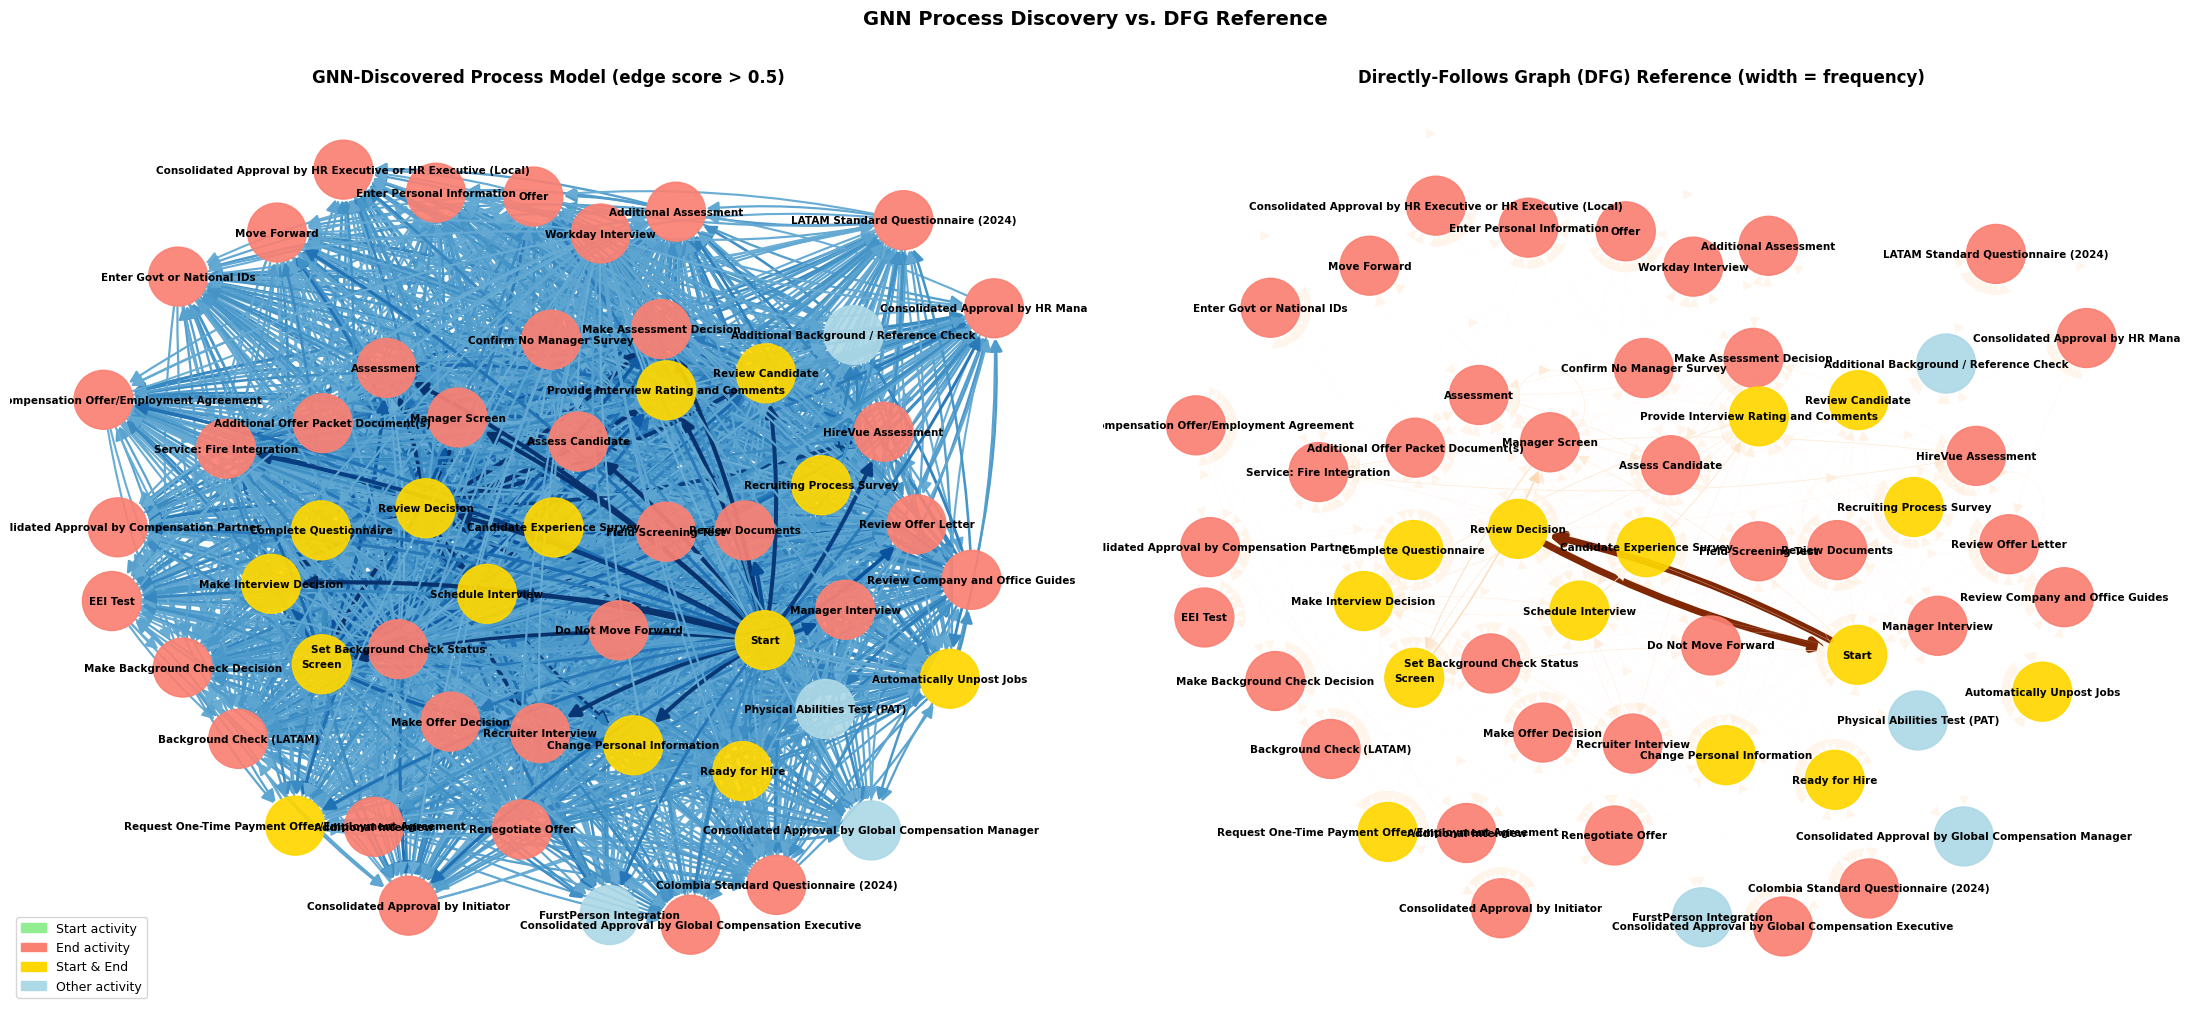

In [ ]:
def node_color(act):
    if act in start_acts and act in end_acts: return 'gold'
    if act in start_acts: return '#90EE90'
    if act in end_acts:   return '#FA8072'
    return '#ADD8E6'

node_colors    = [node_color(a) for a in activities]
legend_handles = [
    mpatches.Patch(color='#90EE90', label='Start activity'),
    mpatches.Patch(color='#FA8072', label='End activity'),
    mpatches.Patch(color='gold',    label='Start & End'),
    mpatches.Patch(color='#ADD8E6', label='Other activity'),
]

try:
    pos = nx.nx_agraph.graphviz_layout(G_gnn, prog='dot')
except Exception:
    pos = nx.spring_layout(G_gnn, seed=42, k=2.5)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

ax = axes[0]
nx.draw_networkx_nodes(G_gnn, pos, ax=ax, nodelist=activities,
                       node_color=node_colors, node_size=1800, alpha=0.92)
nx.draw_networkx_labels(G_gnn, pos, ax=ax, font_size=7.5, font_weight='bold')
if G_gnn.number_of_edges() > 0:
    ew = [G_gnn[u][v]['weight'] for u, v in G_gnn.edges()]
    nx.draw_networkx_edges(G_gnn, pos, ax=ax, width=[w*3 for w in ew],
        edge_color=ew, edge_cmap=plt.cm.Blues, edge_vmin=0, edge_vmax=1,
        arrows=True, arrowsize=18, min_source_margin=22, min_target_margin=22,
        connectionstyle='arc3,rad=0.08')
ax.set_title('GNN-Discovered Process Model (edge score > 0.5)', fontsize=12, fontweight='bold')
ax.axis('off')
ax.legend(handles=legend_handles, loc='lower left', fontsize=9, framealpha=0.8)

ax2  = axes[1]
pos2 = {a: pos[a] for a in G_dfg.nodes() if a in pos}
nc2  = [node_color(a) for a in G_dfg.nodes()]
nx.draw_networkx_nodes(G_dfg, pos2, ax=ax2, node_color=nc2, node_size=1800, alpha=0.92)
nx.draw_networkx_labels(G_dfg, pos2, ax=ax2, font_size=7.5, font_weight='bold')
if G_dfg.number_of_edges() > 0:
    dw  = [G_dfg[u][v]['weight'] for u, v in G_dfg.edges()]
    mxw = max(dw) or 1
    nx.draw_networkx_edges(G_dfg, pos2, ax=ax2, width=[w/mxw*5 for w in dw],
        edge_color=dw, edge_cmap=plt.cm.Oranges,
        arrows=True, arrowsize=18, min_source_margin=22, min_target_margin=22,
        connectionstyle='arc3,rad=0.08')
ax2.set_title('Directly-Follows Graph (DFG) Reference (width = frequency)',
              fontsize=12, fontweight='bold')
ax2.axis('off')

plt.suptitle('GNN Process Discovery vs. DFG Reference', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/gnn_vs_dfg.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6 . Algorithm Comparison


In [ ]:
comparison = pd.DataFrame(scoreboard).T
comparison.index.name = 'Algorithm'
print('=' * 70)
print(' Algorithm Comparison')
print('=' * 70)
print(comparison.to_string())
print()
print('Notes:')
print('  fitness    : token-based replay fitness (1.0 = perfect replay)')
print('  precision  : ETConformance (Petri nets) or edge prec. vs DFG (GNN)')
print('  simplicity : 1 / (1 + arcs/transitions)')
print('  GNN fitness/simplicity: N/A (graph output, not Petri net)')


 Algorithm Comparison
            fitness  precision  simplicity  places  transitions    arcs  edge_recall_vs_dfg  edge_f1_vs_dfg
Algorithm                                                                                                  
Alpha        0.5452     0.1948      0.2808    60.0         54.0   260.0                 NaN             NaN
Inductive    0.9291     0.3585      0.5263    53.0        107.0   232.0                 NaN             NaN
Heuristics   0.9457     0.9936      0.4270   210.0        392.0  1006.0                 NaN             NaN
GNN             NaN     0.4237         NaN     NaN         54.0  2044.0              0.8101          0.5564

Notes:
  fitness    : token-based replay fitness (1.0 = perfect replay)
  precision  : ETConformance (Petri nets) or edge prec. vs DFG (GNN)
  simplicity : 1 / (1 + arcs/transitions)
  GNN fitness/simplicity: N/A (graph output, not Petri net)


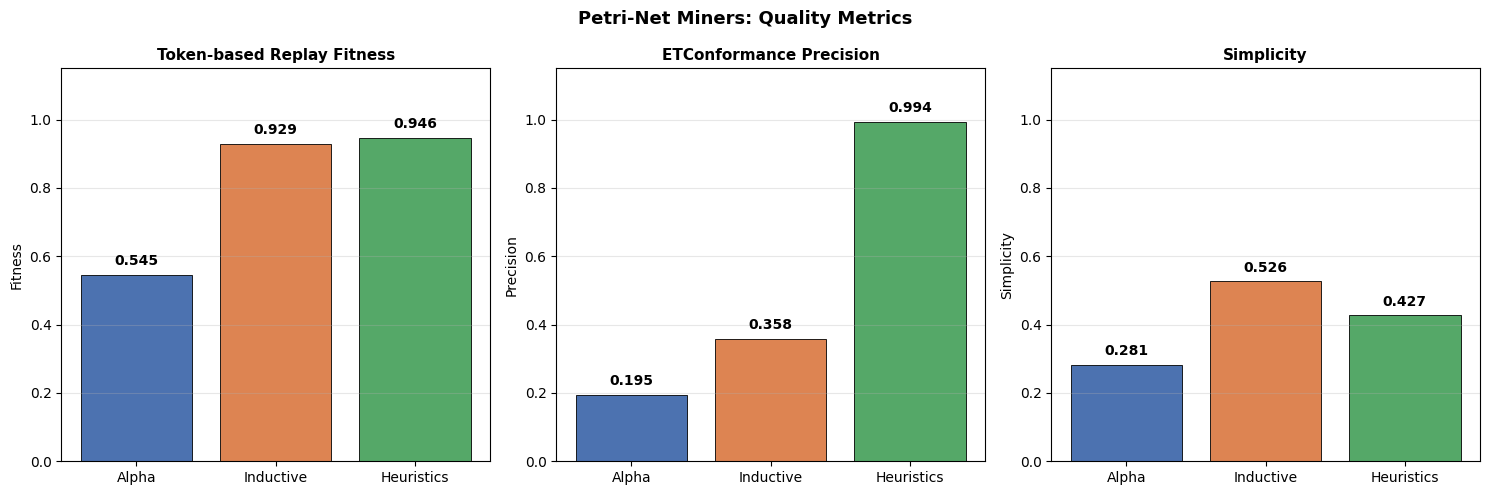

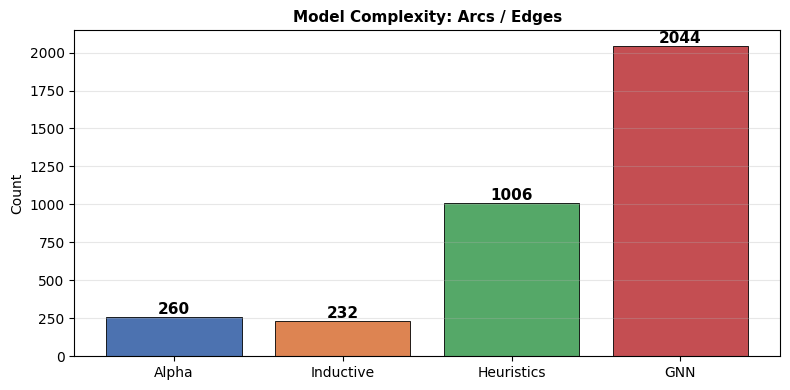

In [ ]:
pn_algos = {k: v for k, v in scoreboard.items()
             if v.get('fitness') is not None and v.get('precision') is not None}

if pn_algos:
    names = list(pn_algos.keys())
    fit   = [pn_algos[n]['fitness']           for n in names]
    prec  = [pn_algos[n]['precision']         for n in names]
    simp  = [pn_algos[n].get('simplicity', 0) or 0 for n in names]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    colors = ['#4C72B0', '#DD8452', '#55A868']
    for ax, vals, ylabel, title in zip(
        axes, [fit, prec, simp],
        ['Fitness', 'Precision', 'Simplicity'],
        ['Token-based Replay Fitness', 'ETConformance Precision', 'Simplicity']
    ):
        bars = ax.bar(names, vals, color=colors, edgecolor='k', linewidth=0.6)
        ax.set_ylim(0, 1.15)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.grid(True, axis='y', alpha=0.3)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, val+0.02, f'{val:.3f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.suptitle('Petri-Net Miners: Quality Metrics', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('output/miner_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

all_names = list(scoreboard.keys())
all_arcs  = [scoreboard[n].get('arcs') or 0 for n in all_names]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(all_names, all_arcs, color=['#4C72B0','#DD8452','#55A868','#C44E52'],
       edgecolor='k', linewidth=0.6)
ax.set_title('Model Complexity: Arcs / Edges', fontsize=11, fontweight='bold')
ax.set_ylabel('Count')
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(all_arcs):
    ax.text(i, v+0.3, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('output/miner_complexity.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7 . Summary

| Algorithm | Strengths | Weaknesses |
|-----------|-----------|------------|
| **Alpha** | Simple, deterministic, interpretable | No noise handling; fails on loops & non-free-choice |
| **Inductive** | Soundness guarantee; handles noise (IMf) | Can over-generalise with high noise threshold |
| **Heuristics** | Handles noise and short loops; frequency-weighted | No soundness guarantee; parameter-sensitive |
| **GNN** | Learns structural roles via message passing; no hand-crafted rules | Requires training; output is graph not Petri net; limited interpretability |

The **Inductive Miner** is the safest choice for downstream conformance checking.  
The **GNN** provides a complementary data-driven view of dominant transitions.  
The **Heuristics Miner** is best for a quick noise-robust model without soundness constraints.
